# Model Training — Employee Emergency Financial Assistance

This notebook trains the Random Forest priority classification model.

## 1. Setup — install and import packages

In [1]:
# shap is not pre-installed on Colab.
!pip install shap -q

import os
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import shap
import joblib

print("Libraries imported. SHAP version:", shap.__version__)

Libraries imported. SHAP version: 0.52.0


## 2. Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR   = '/content/drive/MyDrive/Project'
DATASET_PATH  = os.path.join(PROJECT_DIR, 'Datasets', 'welfare_requests.csv')
LOGS_DIR      = os.path.join(PROJECT_DIR, 'Logs')
CHECKPOINTS_DIR = os.path.join(PROJECT_DIR, 'Checkpoints')

# Confirm the folders are reachable
for p in [PROJECT_DIR, LOGS_DIR, CHECKPOINTS_DIR]:
    print(('OK  ' if os.path.isdir(p) else 'MISSING  '), p)
print(('OK  ' if os.path.isfile(DATASET_PATH) else 'MISSING  '), DATASET_PATH)

Mounted at /content/drive
OK   /content/drive/MyDrive/Project
OK   /content/drive/MyDrive/Project/Logs
OK   /content/drive/MyDrive/Project/Checkpoints
OK   /content/drive/MyDrive/Project/Datasets/welfare_requests.csv


## 3. Clone the GitHub repository


In [3]:
# Clone only if not already present in this session
REPO_URL = 'https://github.com/dylanchezz/Employee-Emergency-Financial-Assistance-Workflow.git'
if not os.path.isdir('Employee-Emergency-Financial-Assistance-Workflow'):
    !git clone {REPO_URL}
else:
    print('Repo already cloned in this session.')
!ls Employee-Emergency-Financial-Assistance-Workflow

Cloning into 'Employee-Emergency-Financial-Assistance-Workflow'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 64 (delta 9), reused 55 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 128.24 KiB | 4.42 MiB/s, done.
Resolving deltas: 100% (9/9), done.
backend  database  docs  frontend  ml-service  README.md


## 4. Load the dataset from Google Drive


In [4]:
df = pd.read_csv(DATASET_PATH)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nPriority class distribution:")
print(df['priority'].value_counts().sort_index().to_string())
print("\nFirst 5 rows:")
df.head()

Shape: (5000, 11)

Columns: ['employee_id', 'department', 'request_date', 'request_category', 'requested_amount', 'salary', 'employment_duration_months', 'previous_requests', 'request_frequency', 'has_documents', 'priority']

Priority class distribution:
priority
High      1667
Low       1677
Medium    1656

First 5 rows:


,employee_id,department,request_date,request_category,requested_amount,salary,employment_duration_months,previous_requests,request_frequency,has_documents,priority
0,EMP100000,Customer Service,30/05/2026,Hardship/Emergency Assistance,29632.30,82542.97,9,3,5,0,Low
1,EMP100001,Sales,06/11/2025,Medical Emergency,6662.93,116072.58,203,7,4,0,Low
2,EMP100002,Procurement,03/10/2025,Education Support,73267.36,53723.40,134,4,3,1,Medium
3,EMP100003,Marketing,08/07/2026,Bereavement,16502.70,54151.36,123,5,4,1,Medium
4,EMP100004,Customer Service,08/01/2026,Bereavement,27116.89,83188.43,49,2,4,1,High


## 5. Prepare the features

- Drop identifier/metadata columns that are not predictive (`employee_id`, `department`, `request_date`).
- Separate the target (`priority`) from the input features.
- One-hot encode the categorical `request_category`.
- Stratified 80/20 train/test split so the held-out test set reflects the same class balance.

In [5]:
TARGET = 'priority'
DROP_COLS = ['employee_id', 'department', 'request_date']

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

# One-hot encode the categorical feature(s)
X = pd.get_dummies(X, columns=['request_category'])

feature_names = list(X.columns)
print("Feature columns used:", feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("\nTrain size:", X_train.shape, " Test size:", X_test.shape)

Feature columns used: ['requested_amount', 'salary', 'employment_duration_months', 'previous_requests', 'request_frequency', 'has_documents', 'request_category_Bereavement', 'request_category_Education Support', 'request_category_Hardship/Emergency Assistance', 'request_category_Medical Emergency']

Train size: (4000, 10)  Test size: (1000, 10)


## 6. Train the model — stratified k-fold cross-validation + grid search



In [6]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_
print("\nBest parameters:", grid.best_params_)
print("Best cross-validation F1 (macro):", round(grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation F1 (macro): 0.8602


## 7. Evaluate on the held-out test set
accuracy, precision, recall, F1, and the confusion matrix — measured on data the model never saw during training.

Accuracy:  0.8530
Precision (macro): 0.8510
Recall (macro):    0.8526
F1-score (macro):  0.8511

Per-class report:

              precision    recall  f1-score   support

        High       0.87      0.90      0.89       334
         Low       0.88      0.92      0.90       335
      Medium       0.81      0.74      0.77       331

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



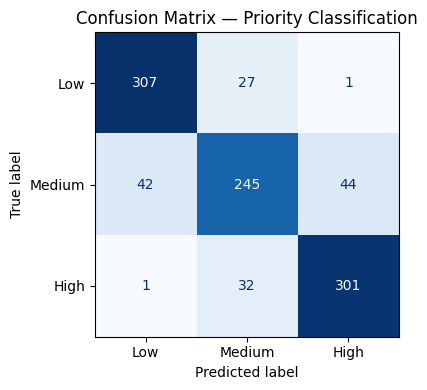

Saved confusion matrix to: /content/drive/MyDrive/Project/Logs/confusion_matrix.png


In [7]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro):    {rec:.4f}")
print(f"F1-score (macro):  {f1:.4f}")
print("\nPer-class report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Priority Classification')
plt.tight_layout()
cm_path = os.path.join(LOGS_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion matrix to:", cm_path)

## 8. SHAP — global feature importance

SHAP (SHapley Additive exPlanations) explains the model's predictions. `TreeExplainer` is
the efficient method for tree-based models like Random Forest.


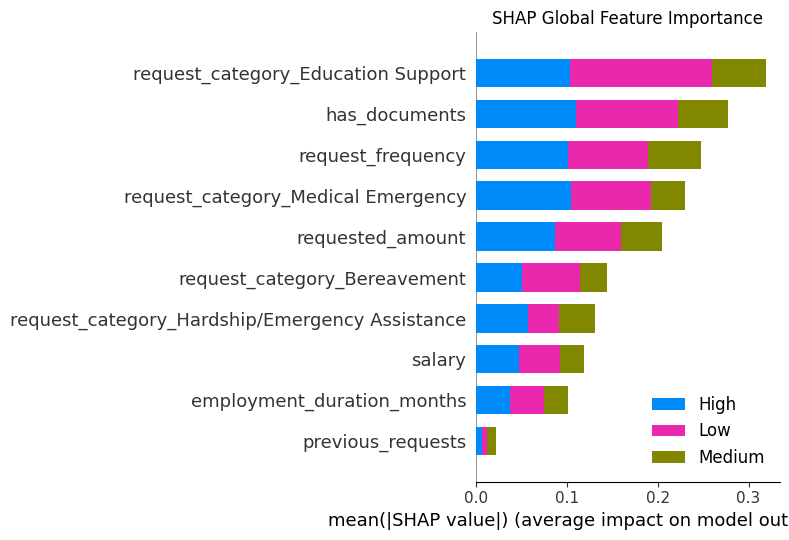

Saved SHAP global importance to: /content/drive/MyDrive/Project/Logs/shap_global_importance.png


In [8]:
explainer = shap.TreeExplainer(model)

# Use a sample of the test set for the global summary (keeps it fast)
X_sample = X_test.sample(min(300, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Global summary plot (bar) averaged across classes
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  class_names=model.classes_, show=False)
plt.title('SHAP Global Feature Importance')
plt.tight_layout()
shap_global_path = os.path.join(LOGS_DIR, 'shap_global_importance.png')
plt.savefig(shap_global_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved SHAP global importance to:", shap_global_path)

## 9. SHAP — per-request explanation

This is the explanation an approver would see for an individual request: the factors that
pushed *this specific request* toward its predicted priority. This demonstrates the
per-request explainability feature.

In [9]:
# Pick one request from the test set to explain
i = 0
single = X_test.iloc[[i]]
pred_label = model.predict(single)[0]
class_idx = list(model.classes_).index(pred_label)

print("Request index:", X_test.index[i])
print("Predicted priority:", pred_label)

# SHAP values for this single request.
# Handle both SHAP output formats:
#   - newer: ndarray of shape (n_samples, n_features, n_classes)
#   - older: list of per-class arrays, each (n_samples, n_features)
sv_single = explainer.shap_values(single)
import numpy as np
if isinstance(sv_single, list):
    contribs = sv_single[class_idx][0]
else:
    arr = np.asarray(sv_single)
    if arr.ndim == 3:          # (samples, features, classes)
        contribs = arr[0, :, class_idx]
    else:                       # (samples, features)
        contribs = arr[0]

contrib_df = pd.DataFrame({
    'feature': single.columns,
    'value': single.iloc[0].values,
    'shap_contribution': contribs
}).sort_values('shap_contribution', key=abs, ascending=False)

print(f"\nTop factors driving the '{pred_label}' prediction for this request:")
print(contrib_df.head(6).to_string(index=False))

Request index: 4481
Predicted priority: Low

Top factors driving the 'Low' prediction for this request:
                           feature     value  shap_contribution
request_category_Education Support      True           0.314741
                  requested_amount  22089.27           0.175031
                 request_frequency         1          -0.148563
request_category_Medical Emergency     False           0.076519
                     has_documents         1          -0.068868
      request_category_Bereavement     False           0.057894


## 10. Save the model and a training log


In [10]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the trained model (final model) to Checkpoints
model_path = os.path.join(CHECKPOINTS_DIR, 'rf_priority_model.joblib')
joblib.dump({'model': model, 'feature_names': feature_names, 'classes': list(model.classes_)},
            model_path)
print("Saved model to:", model_path)

# Also save a timestamped checkpoint copy (for uniformity with the workflow)
checkpoint_copy = os.path.join(CHECKPOINTS_DIR, f'rf_priority_model_{timestamp}.joblib')
joblib.dump({'model': model, 'feature_names': feature_names, 'classes': list(model.classes_)},
            checkpoint_copy)
print("Saved timestamped checkpoint to:", checkpoint_copy)

# Write a training log
log = {
    'timestamp': timestamp,
    'dataset_rows': int(df.shape[0]),
    'train_rows': int(X_train.shape[0]),
    'test_rows': int(X_test.shape[0]),
    'best_params': grid.best_params_,
    'cv_best_f1_macro': round(float(grid.best_score_), 4),
    'test_accuracy': round(float(acc), 4),
    'test_precision_macro': round(float(prec), 4),
    'test_recall_macro': round(float(rec), 4),
    'test_f1_macro': round(float(f1), 4),
    'features': feature_names,
}
log_path = os.path.join(LOGS_DIR, f'training_log_{timestamp}.json')
with open(log_path, 'w') as f:
    json.dump(log, f, indent=2)
print("Saved training log to:", log_path)
print("\nDone. Model, checkpoint, confusion matrix, SHAP plots, and log are in your Drive/Project folders.")

Saved model to: /content/drive/MyDrive/Project/Checkpoints/rf_priority_model.joblib
Saved timestamped checkpoint to: /content/drive/MyDrive/Project/Checkpoints/rf_priority_model_20261001_200711.joblib
Saved training log to: /content/drive/MyDrive/Project/Logs/training_log_20261001_200711.json

Done. Model, checkpoint, confusion matrix, SHAP plots, and log are in your Drive/Project folders.
